In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import contacts
import numpy as np
import matplotlib.pyplot as plt
import os
from multiprocessing import Pool

pdb= './data/top.pdb'
files = []
indir="./data"
for filename in os.listdir(indir):
    if filename.endswith('.xtc'):
        files.append(os.path.join(indir,filename))
    files = sorted(files)

print("Topology: " + pdb)
print("Trajectories: "+ str(files))


Topology: ./data/top.pdb
Trajectories: ['./data/IL0.xtc', './data/NIL0.xtc', './data/c0.xtc', './data/c1.xtc', './data/c2.xtc', './data/c3.xtc', './data/ions0.xtc', './data/test1.xtc']


In [9]:
import pyemma
import MDAnalysis as mda
import numpy as np
from multiprocessing import Pool

pdb = './data/top.pdb'
trajs = ["./data/ions0.xtc"]

u = mda.Universe(pdb, trajs)
num_res = 51
ion_list = ['NA', 'CL', 'CHT', '2HP']

def process_ion(n):
    ion = u.select_atoms(f'resname {n}')
    if len(ion.indices) == 0:
        print(f"No atoms found for ion: {n}")
        return np.zeros(num_res)
    ion_contacts = np.zeros(num_res)
    for r in range(num_res):
        res = u.select_atoms(f'segid A and resid {r+1}')
        if len(res.indices) == 0:
            print(f"No atoms found for residue: {r+1}")
            continue
        contact_feat = pyemma.coordinates.featurizer(pdb)
        contact_feat.add_contacts(indices=ion.indices, indices2=res.indices, threshold=0.45)
        contact_data = pyemma.coordinates.load(trajs, features=contact_feat)

        contact_frame = (contact_data.sum(axis=1) > 0).astype(int)
        total = contact_frame.sum()

        ion_contacts[r] = total / len(contact_frame)
    return ion_contacts

with Pool() as pool:
    results = pool.map(process_ion, ion_list)

contact_matrix = np.array(results)
print(contact_matrix)

25-07-25 11:34:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[0] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[0] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[0] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[0] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:34:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:31 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:34:33 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:34:42 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[4] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:42 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[4] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:45 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[4] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:51 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[4] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:34:53 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[6] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:54 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[6] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:34:59 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[6] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:05 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[8] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:35:13 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[8] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[10] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[10] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[8] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output 

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:35:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[10] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[12] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[12] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[12] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:35:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[16] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[14] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[16] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:35:57 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[12] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:36:03 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[18] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:04 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[18] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:05 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[16] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:12 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[14] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/5 [00:00<?, ?it/s]

25-07-25 11:36:15 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[20] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:16 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[20] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:18 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[18] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:36:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[22] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[22] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[16] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:36:32 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[20] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[24] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:40 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[24] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:43 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[18] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:36:44 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[22] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[26] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[26] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:36:57 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[24] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:37:01 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[20] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:37:02 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[28] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:04 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[28] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:11 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[26] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:37:15 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[30] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:16 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[30] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:16 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[22] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:37:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[28] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[32] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[32] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:31 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[24] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:37:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[30] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:37:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[34] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:40 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[34] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[26] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/8 [00:00<?, ?it/s]

25-07-25 11:37:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[36] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[36] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:37:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[32] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:04 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[38] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:38:15 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[40] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:16 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[40] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:19 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[36] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:38:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[30] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:38:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[42] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[42] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:32 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[38] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[44] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:38:45 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[40] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:51 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[46] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[46] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:38:58 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[42] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:39:01 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[34] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/5 [00:00<?, ?it/s]

25-07-25 11:39:03 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[48] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:04 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[48] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:12 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[44] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:16 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[50] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/8 [00:00<?, ?it/s]

25-07-25 11:39:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[46] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[52] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[52] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:36 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[38] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:39:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[48] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[54] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:40 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[54] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:39:51 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[56] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:39:52 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[50] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:03 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[58] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:03 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[58] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:05 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[52] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:40:08 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[42] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/8 [00:00<?, ?it/s]

25-07-25 11:40:15 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[60] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:15 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[60] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:19 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[54] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[62] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:40:32 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[56] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[64] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[64] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:44 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[58] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/5 [00:00<?, ?it/s]

25-07-25 11:40:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[66] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:51 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[66] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:40:56 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[60] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:00 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[48] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:41:02 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[68] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:03 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[68] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:10 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[62] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:41:14 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[70] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:14 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[70] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[50] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:41:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[64] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[72] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[72] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:35 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[52] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:41:37 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[66] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[74] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[74] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:41:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[68] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:42:02 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[78] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:02 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[70] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:02 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[78] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:42:08 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[56] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:42:14 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[80] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:14 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[80] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:16 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[72] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:42:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[58] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:42:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[82] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[82] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[74] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:42:37 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[84] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:37 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[60] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[84] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:42:44 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[76] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:49 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[86] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[86] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:42:55 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[62] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:42:57 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[78] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:00 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[88] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:02 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[88] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:10 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[80] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:43:14 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[90] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[82] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[92] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[92] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:43:35 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[84] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:43:36 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[94] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:38 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[94] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:47 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[68] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:43:48 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[96] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:49 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[96] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[86] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:43:59 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[98] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the outpu

getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:44:11 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[100] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:44:13 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[100] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:44:17 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[90] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:44:20 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[72] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/8 [00:00<?, ?it/s]

25-07-25 11:44:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[92] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:44:39 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[74] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:44:44 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[94] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:44:57 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[76] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:44:57 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[96] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:45:10 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[98] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:45:14 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[78] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

25-07-25 11:45:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[100] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
25-07-25 11:45:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[80] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:45:43 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[82] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

25-07-25 11:45:59 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[84] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/9 [00:00<?, ?it/s]

25-07-25 11:46:18 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[86] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/3 [00:00<?, ?it/s]

25-07-25 11:46:32 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[88] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:46:50 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[90] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/7 [00:00<?, ?it/s]

25-07-25 11:47:08 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[92] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/8 [00:00<?, ?it/s]

25-07-25 11:47:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[94] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/5 [00:00<?, ?it/s]

25-07-25 11:47:43 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[96] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/5 [00:00<?, ?it/s]

25-07-25 11:47:59 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[98] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/8 [00:00<?, ?it/s]

25-07-25 11:48:18 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[100] WARNING  The 1D arrays input for add_contacts() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


getting output of FeatureReader:   0%|                    | 0/6 [00:00<?, ?it/s]

[[8.79992667e-03 3.58330347e-04 2.79164340e-03 2.66247781e-02
  1.82331814e-02 2.08331597e-04 3.35830535e-03 2.78497679e-02
  2.48497929e-02 2.40997992e-02 1.63331972e-03 4.87495938e-03
  1.05332456e-02 3.08580762e-02 9.24158965e-03 3.33330556e-05
  4.96079199e-02 4.92079233e-02 2.33998050e-02 2.55164540e-02
  6.04494963e-02 9.95825035e-03 1.42832143e-02 1.81165157e-02
  2.05664953e-02 2.29414755e-02 3.56663694e-03 4.36663028e-03
  3.47497104e-03 2.54747877e-02 4.39913001e-02 2.49997917e-05
  4.04163299e-03 3.54330381e-02 5.08329097e-04 1.66665278e-05
  3.11580737e-02 2.62164482e-02 1.39998833e-02 5.31662236e-03
  2.03414972e-02 8.57409522e-02 6.85077624e-02 1.81331822e-02
  1.49082091e-02 4.21579820e-02 1.45498788e-02 1.74748544e-02
  1.50165415e-02 2.86414280e-02 6.08578262e-02]
 [3.60246998e-02 2.89997583e-03 5.92495063e-03 1.91081741e-02
  1.60081999e-02 7.49993750e-05 1.59165340e-03 1.14915709e-02
  1.16832360e-02 1.64915292e-02 5.58328681e-04 1.22498979e-02
  1.71081908e-02 2.821

In [10]:
print(contact_matrix)
np.save('contact_ions.npy', contact_matrix)

[[8.79992667e-03 3.58330347e-04 2.79164340e-03 2.66247781e-02
  1.82331814e-02 2.08331597e-04 3.35830535e-03 2.78497679e-02
  2.48497929e-02 2.40997992e-02 1.63331972e-03 4.87495938e-03
  1.05332456e-02 3.08580762e-02 9.24158965e-03 3.33330556e-05
  4.96079199e-02 4.92079233e-02 2.33998050e-02 2.55164540e-02
  6.04494963e-02 9.95825035e-03 1.42832143e-02 1.81165157e-02
  2.05664953e-02 2.29414755e-02 3.56663694e-03 4.36663028e-03
  3.47497104e-03 2.54747877e-02 4.39913001e-02 2.49997917e-05
  4.04163299e-03 3.54330381e-02 5.08329097e-04 1.66665278e-05
  3.11580737e-02 2.62164482e-02 1.39998833e-02 5.31662236e-03
  2.03414972e-02 8.57409522e-02 6.85077624e-02 1.81331822e-02
  1.49082091e-02 4.21579820e-02 1.45498788e-02 1.74748544e-02
  1.50165415e-02 2.86414280e-02 6.08578262e-02]
 [3.60246998e-02 2.89997583e-03 5.92495063e-03 1.91081741e-02
  1.60081999e-02 7.49993750e-05 1.59165340e-03 1.14915709e-02
  1.16832360e-02 1.64915292e-02 5.58328681e-04 1.22498979e-02
  1.71081908e-02 2.821

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
contact_matrix = np.load('contact_ions.npy')
ion_list = ['Na⁺', 'Cl⁻', 'CDHP⁺', 'DHP⁻']  # Example, replace with your actual list
num_res = contact_matrix.shape[1]

# Set figure size and resolution
fig, ax = plt.subplots(figsize=(12, 4), dpi=1200)

# Plot contact matrix
cax = ax.imshow(contact_matrix, cmap='Blues', aspect='auto')

# Axis ticks and labels
ax.set_xticks(np.arange(num_res))
ax.set_xticklabels([str(i + 1) for i in range(num_res)], fontsize=6) #rotation=90)
ax.set_yticks(np.arange(len(ion_list)))
ax.set_yticklabels(ion_list, fontsize=8)

# Axis labels and title
ax.set_xlabel('Residue Index', fontsize=10)
ax.set_ylabel('Ion Type', fontsize=10)
ax.set_title('Normalised Contacts Between Ions and Residues', fontsize=11)

# Colorbar
cbar = fig.colorbar(cax, ax=ax, shrink=0.8, pad=0.02)
#cbar.set_label('Normalised Contact Frequency', fontsize=9)

# Layout
plt.tight_layout()

# Save as high-quality image (PNG and vector)
plt.savefig('contacts5.png', dpi=1200)
plt.savefig('contacts5.pdf')  # Vector format for publication

# Optional display
plt.show()


In [16]:
import pyemma
import MDAnalysis as mda
import numpy as np
from multiprocessing import Pool

pdb = './data/top.pdb'
trajs = ["./data/ions0.xtc"]

u = mda.Universe(pdb, trajs)
ion_list = ['2HP']

def processmindist(n):
    ions=u.select_atoms(f'resname {n}')
    atom=u.select_atoms('resid 1 and name N')
    mindist_feat=pyemma.coordinates.featurizer(pdb)
    mindist_feat.add_distances(indices=ions.indices, indices2=atom.indices)
    mindist_data=pyemma.coordinates.load(trajs, features=mindist_feat)
    return mindist_data

mindist = processmindist("2HP")

16-04-25 10:47:00 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[4] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


120001
0.45931813
0.02912475729368922


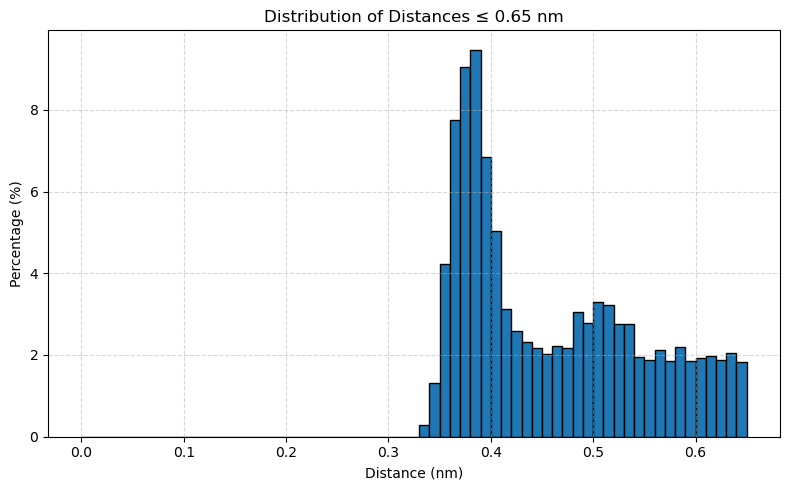

In [17]:
import matplotlib.pyplot as plt
import numpy as np
print(len(mindist))
cutoff=0.65
sum_list = []

for i in range(len(mindist)):
    sort=np.array(mindist[i])
    if sort[0] <= cutoff:
        sum_list.append(sort[0])
print(np.mean(sum_list))

print(len(sum_list)/len(mindist))

binsize = 0.01
nbins = int(cutoff // binsize)
bindist = []
sum_array = np.array(sum_list)

for n in range(nbins):
    bin_min = n * binsize
    bin_max = (n + 1) * binsize
    count = np.sum((sum_array >= bin_min) & (sum_array < bin_max))
    bindist.append(count)

total = sum(bindist)
bindist_percent = [(count / total) * 100 for count in bindist]

# Bin positions
nbins = len(bindist)
bin_edges = np.arange(0, nbins * binsize, binsize)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(bin_edges, bindist_percent, width=binsize, align='edge', edgecolor='black')
plt.xlabel('Distance (nm)')
plt.ylabel('Percentage (%)')
plt.title('Distribution of Distances ≤ {:.2f} nm'.format(cutoff))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("dist_dis1")
plt.show()

In [6]:
import numpy as np
import random
import MDAnalysis as mda
from MDAnalysis.analysis import contacts
from MDAnalysis.coordinates.XTC import XTCWriter

def count_contacts_and_sample_random_frames(ion_residue_info, sample_size=100):
    ions, resid, pdb, traj_files, cutoff_distance, total_frames = ion_residue_info
    
    # Load the Universe for each process
    u = mda.Universe(pdb, traj_files)
    
    ion = u.select_atoms(f'resname {ions}')
    protein_residue = u.select_atoms(f'resid {resid}')
    
    contact_frames = []  # List to store frames where contact is found
    
    # Loop over trajectory frames
    for ts in u.trajectory:
        distances = contacts.distance_array(ion.positions, protein_residue.positions)
        
        # Check if there’s a contact where the distance is less than the cutoff
        if np.sum(distances < cutoff_distance) >= 1:
            contact_frames.append(ts.frame)  # Record the frame with contact
    
    # Randomly sample 100 frames if more than 100 frames were found
    if len(contact_frames) > sample_size:
        contact_frames = random.sample(contact_frames, sample_size)
    os.makedirs(f'{ions}', exist_ok=True)
    # Save the sampled frames to a separate .xtc file for each ion-residue pair
    output_filename = f"{ions}/res{resid}.xtc"
    with XTCWriter(output_filename, u.atoms.n_atoms) as xtc:
        for frame in contact_frames:
            u.trajectory[frame]  # Move to the frame with contact
            xtc.write(u)         # Write the frame to the .xtc file
    
    # Return the filename of saved frames
    return ions, resid, len(contact_frames), output_filename


In [9]:
# Load PDB and trajectory files
pdb = './data/top.pdb'
files = [os.path.join("./data", f) for f in sorted(os.listdir("./data")) if f.endswith('.xtc')]

u = mda.Universe(pdb, './data/test1.xtc')  # Load Universe once to get total_frames
total_frames = len(u.trajectory)
cutoff_distance = 4.5  # Distance cutoff in Angstroms
num_res = 51
ion_list = ['2HP']  # List of ions

ion_residue_pairs = [(ions, resid, pdb, files, cutoff_distance, total_frames) 
                     for ions in ion_list for resid in range(1, num_res + 1)]

# Use multiprocessing Pool to parallelize contact counting and frame saving
with Pool() as pool:
    results = pool.map(count_contacts_and_sample_random_frames, ion_residue_pairs)

# Output files and number of contact frames saved
output_files = {}

for ions, resid, num_saved_frames, filename in results:
    output_files[(ions, resid)] = filename
    print(f"ION-{ions}, RES {resid}: saved {num_saved_frames} frames with contacts to {filename}")

ION-2HP, RES 1: saved 100 frames with contacts to 2HP/res1.xtc
ION-2HP, RES 2: saved 100 frames with contacts to 2HP/res2.xtc
ION-2HP, RES 3: saved 100 frames with contacts to 2HP/res3.xtc
ION-2HP, RES 4: saved 100 frames with contacts to 2HP/res4.xtc
ION-2HP, RES 5: saved 100 frames with contacts to 2HP/res5.xtc
ION-2HP, RES 6: saved 100 frames with contacts to 2HP/res6.xtc
ION-2HP, RES 7: saved 100 frames with contacts to 2HP/res7.xtc
ION-2HP, RES 8: saved 100 frames with contacts to 2HP/res8.xtc
ION-2HP, RES 9: saved 100 frames with contacts to 2HP/res9.xtc
ION-2HP, RES 10: saved 100 frames with contacts to 2HP/res10.xtc
ION-2HP, RES 11: saved 100 frames with contacts to 2HP/res11.xtc
ION-2HP, RES 12: saved 100 frames with contacts to 2HP/res12.xtc
ION-2HP, RES 13: saved 100 frames with contacts to 2HP/res13.xtc
ION-2HP, RES 14: saved 100 frames with contacts to 2HP/res14.xtc
ION-2HP, RES 15: saved 100 frames with contacts to 2HP/res15.xtc
ION-2HP, RES 16: saved 100 frames with cont

In [ ]:
import numpy as np

contacts_data = np.load('contact_times.npy')

# contacts_data has shape (frames, 4n)
frames, cols = contacts_data.shape
n = cols // 4

reshaped = contacts_data.reshape(frames, n, 4)

binary_output = reshaped.any(axis=2).astype(int)

print(binary_output.shape)
print(binary_output)

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Define a custom colormap: white for 0, blue for 1
cmap = ListedColormap(['white', 'black'])

# Plot with discrete colors
fig, ax = plt.subplots(figsize=(15, 6), dpi=1200)
im = ax.imshow(binary_output.T, aspect='auto', cmap=cmap, interpolation='none')

# Labels, ticks, and save as before
ax.set_xlabel("Frame", fontsize=10)
ax.set_ylabel("Ion Index", fontsize=10)
plt.tight_layout()
plt.savefig("contact_timeseries_discrete1.png", dpi=1200)
plt.savefig("contact_timeseries_discrete1.pdf")
plt.show()

In [63]:
import numpy as np
contacts_data = binary_output

def calculate_average_residence_time(contacts_data):
    residence_times = []
    
    # Loop over each contact (column)
    for contact_index in range(contacts_data.shape[1]):
        contact_series = contacts_data[:, contact_index]
        
        # Find transitions from 0 to 1 and 1 to 0
        transitions = np.diff(contact_series)
        start_indices = np.where(transitions == 1)[0] + 1  # Start of a "1" block
        end_indices = np.where(transitions == -1)[0] + 1   # End of a "1" block
        
        # Handle case where series starts or ends with a "1" block
        if contact_series[0] == 1:
            start_indices = np.insert(start_indices, 0, 0)
        if contact_series[-1] == 1:
            end_indices = np.append(end_indices, len(contact_series))
        
        # Calculate residence times for each block
        block_residence_times = end_indices - start_indices
        residence_times.append(np.mean(block_residence_times) if len(block_residence_times) > 0 else 0)

    return residence_times

# Calculate and print the average residence times for each contact
average_residence_times = calculate_average_residence_time(contacts_data)
for i, avg_time in enumerate(average_residence_times):
    print(f"Contact {i + 1}: Average Residence Time = {avg_time:.2f} frames")
print(np.average(average_residence_times))

Contact 1: Average Residence Time = 4.68 frames
Contact 2: Average Residence Time = 4.70 frames
Contact 3: Average Residence Time = 4.45 frames
Contact 4: Average Residence Time = 4.04 frames
Contact 5: Average Residence Time = 3.99 frames
Contact 6: Average Residence Time = 4.71 frames
Contact 7: Average Residence Time = 4.14 frames
Contact 8: Average Residence Time = 4.16 frames
Contact 9: Average Residence Time = 4.37 frames
4.359534826875524
